In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm import tqdm
from PIL import Image as PILImage
from scipy.stats import pearsonr, spearmanr

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [30]:
CSV_PATH   = "data.csv"
IMAGE_DIR  = "AGIQA-3K/"
CHECKPOINT = "checkpoints/best_vit_msqa_model.pth"
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS     = 50
LR         = 1e-5
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs("checkpoints", exist_ok=True)
print(f"Device: {DEVICE}")

Device: cuda


In [27]:
class AGIQADataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["name"])
        image    = PILImage.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        mos = torch.tensor(row["mos_quality"], dtype=torch.float32)
        return image, mos


mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

df = pd.read_csv(CSV_PATH)[["name", "mos_quality"]].dropna()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

n       = len(df)
n_test  = int(n * 0.15)
n_val   = int(n * 0.15)
n_train = n - n_val - n_test

train_df = df.iloc[:n_train]
val_df   = df.iloc[n_train : n_train + n_val]
test_df  = df.iloc[n_train + n_val :]

train_loader = DataLoader(AGIQADataset(train_df, IMAGE_DIR, train_tf),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(AGIQADataset(val_df, IMAGE_DIR, val_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(AGIQADataset(test_df, IMAGE_DIR, val_tf),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Split -- Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Split -- Train: 2088  Val: 447  Test: 447


In [28]:
class MultiScalePooling(nn.Module):
    """Reshape 196 patch tokens into a 14x14 grid and pool at multiple spatial scales."""

    GRID = 14  # ViT-B/16 on 224x224 -> 14x14 patches
    SCALES = [1, 2, 7, 14]  # global(1x1), quadrant(2x2), region(7x7), local(14x14)

    def __init__(self, dim=768):
        super().__init__()
        self.norms = nn.ModuleList([nn.LayerNorm(dim) for _ in self.SCALES])

    def forward(self, patch_tokens):
        B, N, D = patch_tokens.shape
        grid = patch_tokens.transpose(1, 2).reshape(B, D, self.GRID, self.GRID)

        ms_tokens = []
        for scale, norm in zip(self.SCALES, self.norms):
            pooled = F.adaptive_avg_pool2d(grid, scale)          # (B, D, s, s)
            tokens = pooled.flatten(2).transpose(1, 2)           # (B, s*s, D)
            ms_tokens.append(norm(tokens))

        return torch.cat(ms_tokens, dim=1)                       # (B, sum(s*s), D)


class QualityAttentionPool(nn.Module):
    """Learnable quality query attends to multi-scale tokens via cross-attention."""

    def __init__(self, dim=768, num_heads=8, num_queries=1):
        super().__init__()
        self.quality_queries = nn.Parameter(torch.randn(1, num_queries, dim) * 0.02)
        self.cross_attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm       = nn.LayerNorm(dim)
        self.ffn        = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Linear(dim * 2, dim),
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, ms_tokens):
        B = ms_tokens.size(0)
        q = self.quality_queries.expand(B, -1, -1)
        attn_out, attn_weights = self.cross_attn(q, ms_tokens, ms_tokens)
        x = self.norm(attn_out + q)
        x = self.norm2(x + self.ffn(x))
        return x.squeeze(1), attn_weights


class ViTMSQA(nn.Module):
    """ViT-B/16 with Multi-Scale Quality Attention pooling for IQA.

    Instead of using only the CLS token, this model:
      1. Extracts all 196 patch tokens from the ViT encoder.
      2. Pools them at 4 spatial scales (1x1, 2x2, 7x7, 14x14) to capture
         both global composition and local artifact information.
      3. Uses a learnable quality query with cross-attention to aggregate
         the multi-scale tokens into a single quality-aware representation.
      4. Concatenates the CLS token (global semantic summary) with the
         quality-attended representation for the final regression.
    """

    def __init__(self, dropout=0.3):
        super().__init__()
        vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

        self.patch_embed = vit.conv_proj
        self.cls_token   = vit.class_token
        self.pos_embed   = vit.encoder.pos_embedding
        self.encoder     = vit.encoder.layers
        self.enc_norm    = vit.encoder.ln

        self.ms_pool     = MultiScalePooling(dim=768)
        self.qa_pool     = QualityAttentionPool(dim=768, num_heads=8)

        # CLS (768) + quality-attended (768) = 1536
        self.head = nn.Sequential(
            nn.Linear(768 * 2, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1),
        )

    def extract_tokens(self, x):
        """Run ViT encoder and return (cls_token, patch_tokens)."""
        x = self.patch_embed(x)                           # (B, 768, 14, 14)
        x = x.flatten(2).transpose(1, 2)                  # (B, 196, 768)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)            # (B, 1, 768)
        x = torch.cat([cls, x], dim=1)                    # (B, 197, 768)
        x = x + self.pos_embed
        x = self.encoder(x)
        x = self.enc_norm(x)
        return x[:, 0], x[:, 1:]                          # cls(B,768), patches(B,196,768)

    def forward(self, x):
        cls_token, patch_tokens = self.extract_tokens(x)
        ms_tokens = self.ms_pool(patch_tokens)            # (B, 250, 768)
        qa_repr, self._attn_w = self.qa_pool(ms_tokens)   # (B, 768)
        fused = torch.cat([cls_token, qa_repr], dim=-1)   # (B, 1536)
        return self.head(fused).squeeze(-1)


model     = ViTMSQA(dropout=0.3).to(DEVICE)
criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

total   = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,}  Trainable: {train_p:,}")

ms_token_count = sum(s*s for s in MultiScalePooling.SCALES)
print(f"Multi-scale tokens per image: {ms_token_count} "
      f"(scales {MultiScalePooling.SCALES} -> {[s*s for s in MultiScalePooling.SCALES]})")

Total params: 91,385,345  Trainable: 91,385,345
Multi-scale tokens per image: 250 (scales [1, 2, 7, 14] -> [1, 4, 49, 196])


In [31]:
history = {"train_loss": [], "val_loss": [], "val_srcc": [], "val_plcc": []}
best_val_srcc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, num_samples = 0.0, 0
    for images, scores in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        images, scores = images.to(DEVICE), scores.to(DEVICE)
        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, scores)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        num_samples  += images.size(0)

    model.eval()
    val_running, val_n = 0.0, 0
    all_preds, all_gt = [], []
    with torch.no_grad():
        for images, scores in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]  "):
            images, scores = images.to(DEVICE), scores.to(DEVICE)
            preds = model(images)
            val_running += criterion(preds, scores).item() * images.size(0)
            val_n       += images.size(0)
            all_preds.append(preds.cpu().numpy())
            all_gt.append(scores.cpu().numpy())

    train_loss = running_loss / num_samples
    val_loss   = val_running / val_n
    p_arr = np.concatenate(all_preds)
    g_arr = np.concatenate(all_gt)
    val_srcc, _ = spearmanr(p_arr, g_arr)
    val_plcc, _ = pearsonr(p_arr, g_arr)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_srcc"].append(val_srcc)
    history["val_plcc"].append(val_plcc)

    cur_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | SRCC: {val_srcc:.4f} | "
          f"PLCC: {val_plcc:.4f} | LR: {cur_lr:.2e}")

    if val_srcc > best_val_srcc:
        best_val_srcc = val_srcc
        torch.save({"epoch": epoch, "model_state": model.state_dict(),
                    "val_srcc": val_srcc}, CHECKPOINT)
        print(f"  -> Saved best model (SRCC={val_srcc:.4f})")

print("Training complete!")

Epoch 1/50 [val]  : 100%|██████████| 28/28 [00:01<00:00, 15.57it/s]


Epoch   1 | Loss: 0.1232 | Val Loss: 0.1828 | SRCC: 0.8254 | PLCC: 0.8729 | LR: 9.99e-06
  -> Saved best model (SRCC=0.8254)


Epoch 2/50 [val]  : 100%|██████████| 28/28 [00:01<00:00, 15.34it/s]


Epoch   2 | Loss: 0.0954 | Val Loss: 0.1531 | SRCC: 0.8367 | PLCC: 0.8811 | LR: 9.96e-06
  -> Saved best model (SRCC=0.8367)


Epoch 3/50 [val]  : 100%|██████████| 28/28 [00:01<00:00, 15.31it/s]


...

Epoch  48 | Loss: 0.0190 | Val Loss: 0.1016 | SRCC: 0.8555 | PLCC: 0.8968 | LR: 1.39e-07


Epoch 49/50 [val]  : 100%|██████████| 28/28 [00:01<00:00, 14.69it/s]


Epoch  49 | Loss: 0.0193 | Val Loss: 0.1016 | SRCC: 0.8554 | PLCC: 0.8968 | LR: 1.10e-07


Epoch 50/50 [val]  : 100%|██████████| 28/28 [00:02<00:00, 13.44it/s]

Epoch  50 | Loss: 0.0180 | Val Loss: 0.1022 | SRCC: 0.8554 | PLCC: 0.8965 | LR: 1.00e-07
Training complete!


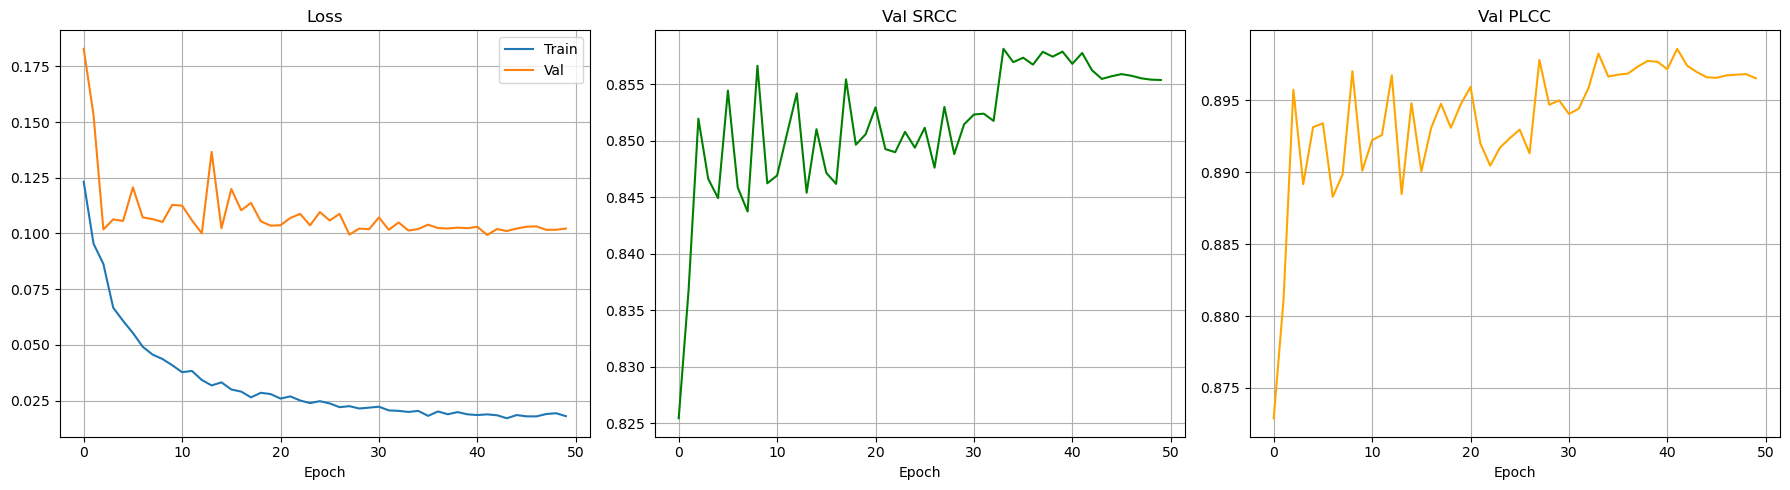

In [32]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True)

ax2.plot(history["val_srcc"], color="green")
ax2.set_title("Val SRCC"); ax2.set_xlabel("Epoch"); ax2.grid(True)

ax3.plot(history["val_plcc"], color="orange")
ax3.set_title("Val PLCC"); ax3.set_xlabel("Epoch"); ax3.grid(True)

plt.tight_layout()
plt.savefig("training_curves_vit_msqa.png")
plt.show()

Loaded best model from epoch 34 (SRCC=0.8581)



Testing: 100%|██████████| 28/28 [00:01<00:00, 15.67it/s]

Test Results (ViT-MSQA)
  SRCC : 0.8399
  PLCC : 0.8984
  RMSE : 0.4508


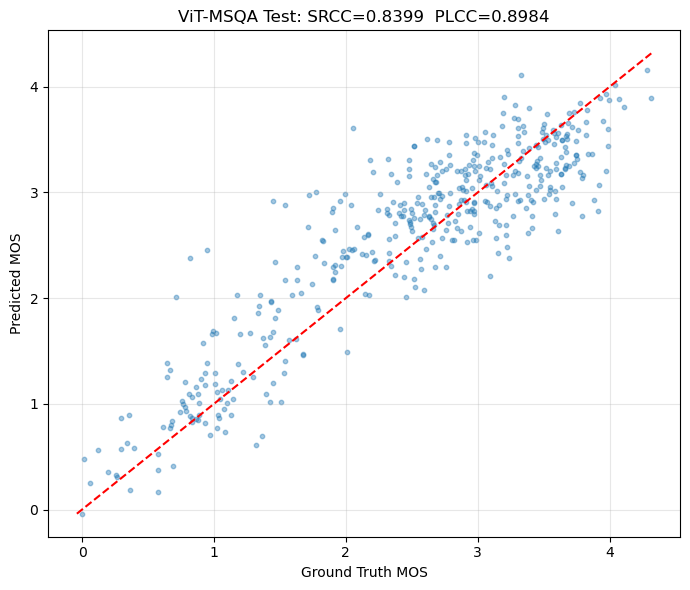

In [33]:
ckpt = torch.load(CHECKPOINT, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model from epoch {ckpt['epoch']} (SRCC={ckpt['val_srcc']:.4f})\n")

model.eval()
all_preds, all_gt = [], []
with torch.no_grad():
    for images, scores in tqdm(test_loader, desc="Testing"):
        preds = model(images.to(DEVICE)).cpu().numpy()
        all_preds.append(preds)
        all_gt.append(scores.numpy())

preds_arr = np.concatenate(all_preds)
gt_arr    = np.concatenate(all_gt)

srcc, _ = spearmanr(gt_arr, preds_arr)
plcc, _ = pearsonr(gt_arr, preds_arr)
rmse    = np.sqrt(np.mean((gt_arr - preds_arr) ** 2))

print("=" * 40)
print("Test Results (ViT-MSQA)")
print("=" * 40)
print(f"  SRCC : {srcc:.4f}")
print(f"  PLCC : {plcc:.4f}")
print(f"  RMSE : {rmse:.4f}")
print("=" * 40)

plt.figure(figsize=(7, 6))
plt.scatter(gt_arr, preds_arr, alpha=0.4, s=10)
lo, hi = min(gt_arr.min(), preds_arr.min()), max(gt_arr.max(), preds_arr.max())
plt.plot([lo, hi], [lo, hi], "r--")
plt.xlabel("Ground Truth MOS")
plt.ylabel("Predicted MOS")
plt.title(f"ViT-MSQA Test: SRCC={srcc:.4f}  PLCC={plcc:.4f}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("test_scatter_vit_msqa.png")
plt.show()

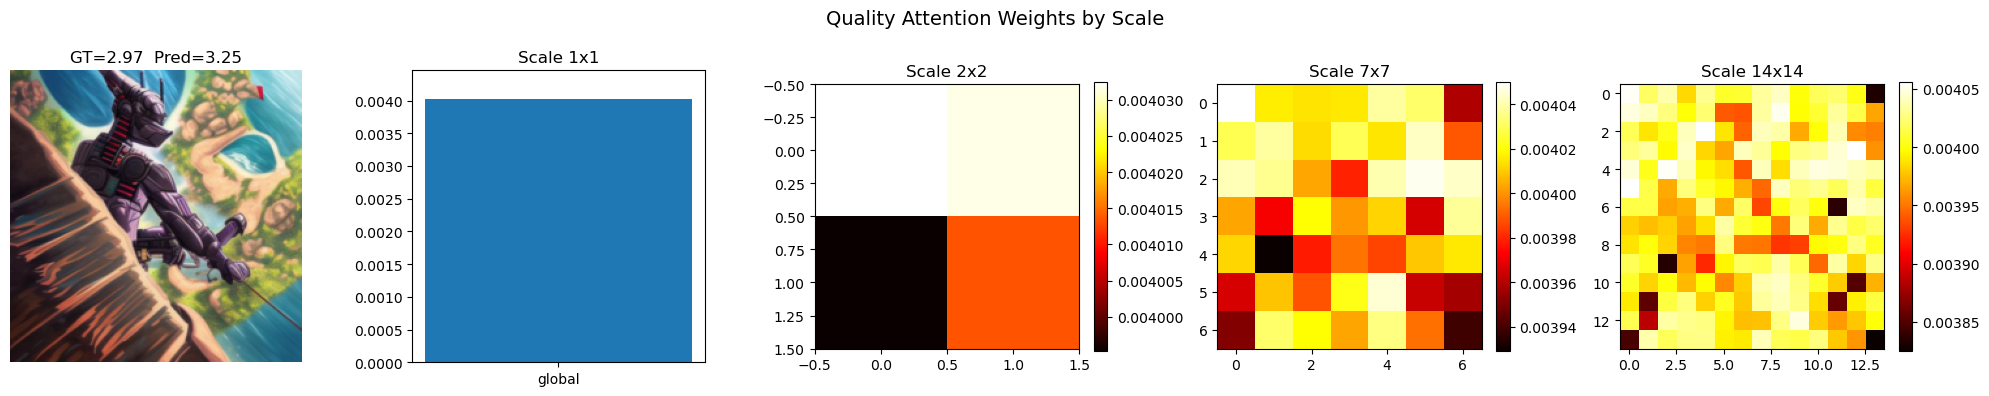

In [34]:
"""Visualise quality attention weights on a sample image.
Shows which spatial regions (at each scale) the model attends to most."""

model.eval()
sample_img, sample_mos = next(iter(test_loader))
sample_img = sample_img[:1].to(DEVICE)

with torch.no_grad():
    pred = model(sample_img)
    attn_w = model._attn_w[0, 0].cpu().numpy()  # (num_ms_tokens,)

scales = MultiScalePooling.SCALES
scale_sizes = [s * s for s in scales]
scale_names = [f"{s}x{s}" for s in scales]

fig, axes = plt.subplots(1, len(scales) + 1, figsize=(4 * (len(scales) + 1), 4))

inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)
vis_img = inv_norm(sample_img[0].cpu()).permute(1, 2, 0).clamp(0, 1).numpy()
axes[0].imshow(vis_img)
axes[0].set_title(f"GT={sample_mos[0]:.2f}  Pred={pred[0]:.2f}")
axes[0].axis("off")

offset = 0
for i, (s, n, name) in enumerate(zip(scales, scale_sizes, scale_names)):
    w = attn_w[offset : offset + n].reshape(s, s)
    offset += n
    if s == 1:
        axes[i + 1].bar(["global"], [w.item()])
        axes[i + 1].set_ylim(0, attn_w.max() * 1.1)
    else:
        im = axes[i + 1].imshow(w, cmap="hot", interpolation="nearest")
        plt.colorbar(im, ax=axes[i + 1], fraction=0.046)
    axes[i + 1].set_title(f"Scale {name}")

plt.suptitle("Quality Attention Weights by Scale", fontsize=14)
plt.tight_layout()
plt.savefig("attn_viz_msqa.png")
plt.show()